# **Experiment Notebook**



In [1]:
import sys
!{sys.executable} -m pip install -U utstd

In [2]:
# Do not modify this code
!pip install -q utstd

In [3]:
from utstd.ipyrenders import *

In [4]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [5]:
!/Users/huhyoon/opt/anaconda3/envs/at1-3114-py3114/bin/pip install -U -i https://test.pypi.org/simple at1package==0.0.7 --no-deps

Looking in indexes: https://test.pypi.org/simple


In [6]:
import at1package
import pandas as pd
import numpy as np

---
## A. Project Description


In [7]:
# <Student to fill this section>
student_name = "Yoon Huh"
student_id = "25656075"
group_id = "23"

In [8]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [9]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [10]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [11]:
# <Student to fill this section>
business_use_case_description = """
The goal of this project is to predict whether a college basketball player will be drafted into the NBA, based on their performance statistics.
Accurate predictions can help scouts and teams prioritize their attention and resources, while also generating insights for sports commentators and fans.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [13]:
# <Student to fill this section>
business_objectives = """
Accurate predictions will allow NBA teams to identify promising players more effectively, potentially gaining a competitive advantage in drafting decisions. 
On the other hand, incorrect predictions may lead to missed opportunities or wasted scouting resources, which can negatively impact team performance and financial investments."""

In [14]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [15]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The primary users of the predictions are NBA teams, scouts, and analysts who rely on data-driven insights to guide draft decisions. 
Secondary stakeholders include sports commentators, media, and fans who use the predictions to follow player prospects. 
Players themselves may also be indirectly affected as predictive models can influence perceptions of their draft potential.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [17]:
from pathlib import Path

train_df  = pd.read_csv("train.csv")
test_df   = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

# metadata can have non-utf8 characters, so try a fallback encoding
try:
    meta_df = pd.read_csv("metadata.csv")
except UnicodeDecodeError:
    meta_df = pd.read_csv("metadata.csv", encoding="latin1")

### C.2 Explore Datasets

#### C.2.1 Dataset Structure

In [18]:
print("Shapes ->",
      "train:", train_df.shape,
      "test:", test_df.shape,
      "sample:", sample_sub.shape,
      "meta:", meta_df.shape)

display(train_df.head(3))
display(test_df.head(3))
display(sample_sub.head(3))
display(meta_df.head(3))

Shapes -> train: (14774, 62) test: (1297, 61) sample: (1297, 2) meta: (62, 3)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id
0,UC Davis,BW,8,2.2,51.7,13.4,30.0,30.00,0.0,14.3,...,-11.240100,-4.721030,0.1000,0.6000,0.7000,0.2000,0.1000,0.0000,1.5000,c6d3ce49-28b6-4756-8061-b2bd68730c52
1,Campbell,BSth,25,16.4,85.0,25.2,50.0,52.10,2.0,11.8,...,-2.972020,-1.741870,0.1481,0.9259,1.0741,0.1481,0.4074,0.1111,4.0741,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5
2,Weber St.,BSky,29,50.5,117.8,16.8,61.8,59.77,12.3,17.1,...,0.739055,-0.259202,2.1562,2.7500,4.9062,0.7188,0.4062,1.0625,6.7500,0cf3e822-9446-4285-b7ed-7c19d8e976fe


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.51
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.92
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.14


,feature,name,description
0,1,team,Name of team
1,2,conf,Name of conference
2,3,GP,Games played


The dataset consists of four files: `train.csv`, `test.csv`, `sample_submission.csv`, and `metadata.csv`.  
- **Train set:** 14,774 rows × 62 columns including the target variable `drafted`.  
- **Test set:** 1,297 rows × 61 columns excluding the target variable `drafted`.  
- **Sample submission:** 1,297 rows × 2 columns (`player_id`, `drafted`) that provides the required output format for Kaggle submissions.  
- **Metadata:** 62 rows × 3 columns describing each feature name and its meaning. (`feature`, `name`, `description`)

This confirms that the train and test sets are aligned in terms of features, except that the target variable is only present in the train set.

#### C.2.2 Data Types

In [19]:
# Check data types and missing values for train/test
print("Train info:")
train_df.info()

print("\nTest info:")
test_df.info()

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 14774 non-null  object 
 1   conf                 14774 non-null  object 
 2   GP                   14774 non-null  int64  
 3   Min_per              14774 non-null  float64
 4   Ortg                 14774 non-null  float64
 5   usg                  14774 non-null  float64
 6   eFG                  14774 non-null  float64
 7   TS_per               14774 non-null  float64
 8   ORB_per              14774 non-null  float64
 9   DRB_per              14774 non-null  float64
 10  AST_per              14774 non-null  float64
 11  TO_per               14774 non-null  float64
 12  FTM                  14774 non-null  int64  
 13  FTA                  14774 non-null  int64  
 14  FT_per               14774 non-null  float64
 15  twoPM                147

- **Train set (62 columns, 14,774 rows):**  
  - **Numerical features:** 48 float64 and 8 int64 variables (e.g., `pts`, `TS_per`, `ast`, `bpm`).  
  - **Categorical features:** 6 object variables (`team`, `conf`, `yr`, `ht`, `type`, `player_id`).  
  - **Target variable:** `drafted` (float64).  
  - Some columns show partial missingness. 

- **Test set (61 columns, 1,297 rows):**  
  - Matches the structure of the train set except that `drafted` is absent.  
  - Contains the same 6 categorical variables.  
  - Missing values are also present in the same features.

This confirms that the dataset is predominantly numerical with a few categorical identifiers, and that missing values are concentrated in specific advanced statistical features (e.g., `Rec_Rank`, `rim_ratio`, `dunks_ratio`).

In [20]:
from at1package.features import clean_conf_upper

train_df = clean_conf_upper(train_df, col="conf")
test_df  = clean_conf_upper(test_df,  col="conf")

#### C.2.3 Summary Statistics

In [21]:
# Summary statistics for numerical features
print("Train summary statistics:")
display(train_df.describe().head(5))

Train summary statistics:


,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,drafted
count,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,...,14769.000000,14769.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14774.000000
mean,21.251726,25.870123,85.771707,17.256674,41.507628,44.566821,5.644010,11.992744,9.776100,21.493326,...,-3.376953,-0.757406,0.552453,1.269347,1.821801,0.717322,0.368722,0.206213,3.662676,0.007987
std,10.517642,23.639878,34.164203,6.332899,20.610900,19.622173,15.097867,15.348129,9.906416,13.979387,...,6.613226,3.773361,0.585068,1.125643,1.625416,0.897261,0.375689,0.343153,3.623175,0.089015
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-106.262000,-71.527600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,4.200000,75.600000,13.900000,34.800000,38.820000,1.600000,7.500000,3.200000,14.900000,...,-5.738050,-2.138620,0.138900,0.428600,0.625000,0.125000,0.083300,0.000000,1.000000,0.000000


Summary statistics for numerical features were generated using the `.describe()` method.  
For the train set, the first few features show reasonable averages and standard deviations consistent with basketball performance metrics. The minimum values for many statistics are 0, while some features include high maximums that suggest the presence of outliers.

#### C.2.4 Missing Values

In [22]:
# Check missing values in train set
print("Missing values in train:")
missing_train = train_df.isna().sum().sort_values(ascending=False)
print(missing_train[missing_train > 0])

# Check missing values in test set
print("\nMissing values in test:")
missing_test = test_df.isna().sum().sort_values(ascending=False)
print(missing_test[missing_test > 0])

# Quick percentage view
print("\nPercentage of missing values in train:")
print((train_df.isna().mean() * 100).sort_values(ascending=False).head(10))

Missing values in train:
Rec_Rank               9885
dunks_ratio            9388
rim_ratio              3203
mid_ratio              3191
rimmade_rimmiss        2075
midmade                2075
midmade_midmiss        2075
dunksmade              2075
dunksmiss_dunksmade    2075
rimmade                2075
ast_tov                1535
ht                        8
dgbpm                     5
stops                     5
ogbpm                     5
adrtg                     5
dporpag                   5
drtg                      5
bpm                       5
dbpm                      5
gbpm                      5
obpm                      5
oreb                      1
dreb                      1
treb                      1
ast                       1
mp                        1
stl                       1
blk                       1
pts                       1
dtype: int64

Missing values in test:
Rec_Rank               894
dunks_ratio            738
mid_ratio              196
rim_ratio       

An assessment of missing values was performed for both the train and test sets.  

- **Train set:**  
  - Several advanced metrics have substantial missingness.  
  - `Rec_Rank` is missing for ~67% of players.  
  - `dunks_ratio` is missing for ~64%.  
  - `rim_ratio` ~22% and `mid_ratio` ~22% also show notable gaps.  
  - A group of features related to shot types (`rimmade`, `midmade`, `dunksmade` and their ratios) have ~14% missing.  
  - A few features (`ast_tov`) have moderate missingness ~10%.  
  - Basic box score stats (`pts`, `ast`, `reb`, `blk`, etc.) are almost complete with only 1–8 missing values.  

- **Test set:**  
  - Missingness patterns mirror the train set. `Rec_Rank`, `dunks_ratio`, `rim_ratio`, and `mid_ratio` remain the most affected.  
  - Simpler counting stats remain nearly complete.  

These results confirm that missing values are concentrated in **advanced efficiency metrics**, while core performance indicators (e.g., points, assists, rebounds) are essentially complete.  
Such findings will guide later decisions in the **Data Preparation (Cleaning)** stage where options include imputation, feature removal, or engineered replacements.

#### C.2.5 Duplicates

In [23]:
# Check duplicates in train set
print("Total rows in train:", len(train_df))
print("Duplicate rows (all columns identical):", train_df.duplicated().sum())

# Check duplicate player_id
dup_ids = train_df['player_id'].duplicated().sum()
print("Duplicate player_id count:", dup_ids)

# Find examples of players with multiple records
dup_samples = train_df[train_df['player_id'].duplicated(keep=False)]
print("Number of unique duplicated player_id:", dup_samples['player_id'].nunique())
dup_samples.head()

Total rows in train: 14774
Duplicate rows (all columns identical): 2462
Duplicate player_id count: 2619
Number of unique duplicated player_id: 2555


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0
5,Delaware St.,MEAC,6,1.4,19.5,8.5,0.0,0.00,7.5,7.6,...,-6.05569,0.1667,0.1667,0.3333,0.0000,0.0000,0.0000,0.0000,9cd0e4eb-61ff-4a32-9005-5b6231ea1fe9,0
31,Alabama St.,SWAC,5,1.7,81.9,29.7,27.8,35.18,12.1,20.9,...,-2.02590,0.4000,0.8000,1.2000,0.4000,0.2000,0.0000,1.4000,a5778286-1624-4f3f-864b-34cde9b161b5,0
39,Western Carolina,SC,28,51.0,81.9,21.3,39.0,41.29,7.7,14.6,...,-2.10538,1.5357,2.4286,3.9643,0.9643,1.0000,0.2143,6.2143,da582f43-f01d-409d-b9ca-6142a52c883d,0
44,Tennessee Tech,OVC,9,1.3,60.2,19.7,25.0,20.20,7.1,0.0,...,0.96349,0.1111,0.0000,0.1111,0.2222,0.2222,0.0000,0.2222,a384ca1f-1595-4deb-8db9-ef1b4ed6ac86,0


Duplicate checks in the training set revealed that:  
- Out of 14,774 rows, there are **2,462 fully duplicated rows** (all column values identical).  
- Additionally, **2,619 rows share duplicated `player_id`s**, corresponding to **2,555 unique players**.  
- These repeated players likely reflect multiple seasons or contexts for the same athlete rather than strict duplicates.  

For the Data Exploration stage, duplicates are retained to avoid altering the dataset.  
In the **Data Preparation stage**, I will:  
- Remove the fully duplicated rows, as they add no new information.  
- Carefully assess repeated `player_id`s with differing values since they may contain season-specific information that should be preserved.  

### C.3 Define Target variable

In [24]:
# <Student to fill this section>
target_definition_explanations = """
I define the target variable as `drafted` in train.csv. It is a binary label indicating whether a college player was drafted into the NBA (1) or not (0).
The model will output a probability between 0 and 1 for each player in the test set. Kaggle requires a submission with two columns: player_id and drafted (probability)."""

In [25]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.4 Create Target variable

In [26]:
# Create target variable and ID variable
target_name = "drafted"
id_col = "player_id"

### C.5 Explore Target variable

In [27]:
import matplotlib.pyplot as plt

# 1. Basic checks
assert target_name in train_df.columns, f"Target '{target_name}' not found in train_df"
assert id_col in train_df.columns, f"ID column '{id_col}' not found in train_df"
assert id_col in test_df.columns, f"ID column '{id_col}' not found in test_df"

y = train_df[target_name]

print("---- Target summary ----")
print("dtype:", y.dtype)
print("Missing count:", y.isna().sum())
print("Unique values:", sorted(pd.Series(y.dropna().unique()).tolist()))

# 2. Class counts and proportions
counts = y.value_counts(dropna=False).sort_index()
props  = y.value_counts(normalize=True, dropna=False).sort_index()

display(pd.DataFrame({"count": counts, "proportion": props}))

---- Target summary ----
dtype: int64
Missing count: 0
Unique values: [0, 1]


,count,proportion
drafted,,
0,14656,0.992013
1,118,0.007987


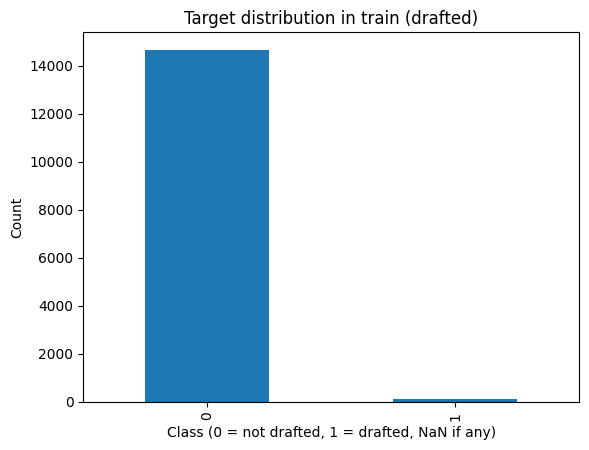

Positive class rate (drafted=1): 0.008
OK: test_df has no target column.
Duplicated player_id in train: 2619


In [28]:
# 3. Bar plot for class balance
plt.figure()
counts.plot(kind="bar")
plt.title("Target distribution in train (drafted)")
plt.xlabel("Class (0 = not drafted, 1 = drafted, NaN if any)")
plt.ylabel("Count")
plt.show()

# 4. Positive class rate (drafted = 1). This is for imbalance severity.
if set(counts.index).issuperset({0, 1}):
    pos_rate = props.get(1, float('nan'))
    print(f"Positive class rate (drafted=1): {pos_rate:.3f}")
else:
    print("Note: Target is not strictly binary 0/1 after reading; verify encoding.")

# 5. Ensure the target column doesn't exist in test to prevent leakage.
if target_name in test_df.columns:
    print("WARNING: target column appears in test_df; drop it before modeling.")
else:
    print("OK: test_df has no target column.")

# 6. Check duplicated IDs
dup_ids = train_df[id_col].duplicated().sum()
print(f"Duplicated {id_col} in train: {dup_ids}")

In [29]:
# <Student to fill this section>
target_distribution_explanations = """
The target variable `drafted` is highly imbalanced.
- The positive class (drafted = 1) represents only ~0.8% of the training data.  
- The majority of players are labeled as not drafted (0).  

This imbalance has important implications:
- Standard accuracy would be misleading, because a trivial model predicting "not drafted" for all players would still achieve high accuracy.  
- The chosen metric AUROC is appropriate, since it evaluates the ranking quality of predicted probabilities rather than relying on raw accuracy.  
- May need to consider resampling techniques (e.g., SMOTE, undersampling) or class-weight adjustments during modeling to address the severe imbalance.  

Additionally, 2,619 duplicated player_id values were found in the training set.  
- This will need to be investigated further to determine whether they represent multiple seasons per player or actual duplicates.  
- Careful handling is required to avoid information leakage and biased evaluation."""

In [30]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.6 Explore Feature of Interest `conference`

In [31]:
# 1. Basic frequency counts
conf_counts = train_df['conf'].value_counts()
print("Number of unique conferences:", train_df['conf'].nunique())
print(conf_counts.head(10))

# 1.1 Detect case inconsistencies (example: 'Ind' vs 'ind')
print("Example values for 'Ind':",
      [c for c in train_df['conf'].unique() if isinstance(c, str) and c.lower() == "ind"])

# 1.2 Normalise to uppercase (apply to both train and test for consistency)
train_df['conf'] = train_df['conf'].str.upper()
test_df['conf'] = test_df['conf'].str.upper()

# 1.3 Frequency counts (after cleaning)
conf_counts = train_df['conf'].value_counts()
print("Number of unique conferences (cleaned):", train_df['conf'].nunique())
print(conf_counts.head(10))

Number of unique conferences: 35
conf
ACC     652
SEC     645
A10     624
B10     599
CUSA    583
BE      568
MAC     536
BSTH    477
SC      475
MEAC    474
Name: count, dtype: Int64
Example values for 'Ind': ['IND']
Number of unique conferences (cleaned): 35
conf
ACC     652
SEC     645
A10     624
B10     599
CUSA    583
BE      568
MAC     536
BSTH    477
SC      475
MEAC    474
Name: count, dtype: Int64


In [32]:
# 2. Draft rate per conference
conf_draft_rate = (
    train_df.groupby('conf')[target_name]
    .mean()
    .sort_values(ascending=False)
)

print("Draft rate by conference (top 10):")
print(conf_draft_rate.head(10))

Draft rate by conference (top 10):
conf
SEC     0.052713
P12     0.045455
B12     0.038793
ACC     0.033742
BE      0.012324
P10     0.012048
B10     0.011686
MWC     0.007075
CUSA    0.006861
A10     0.003205
Name: drafted, dtype: float64


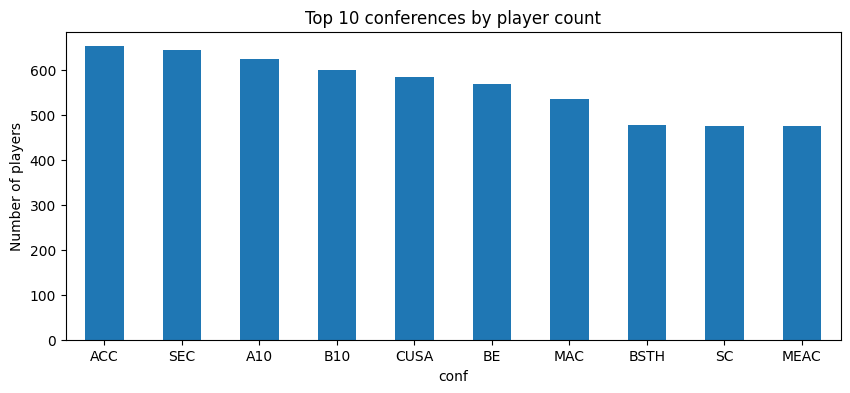

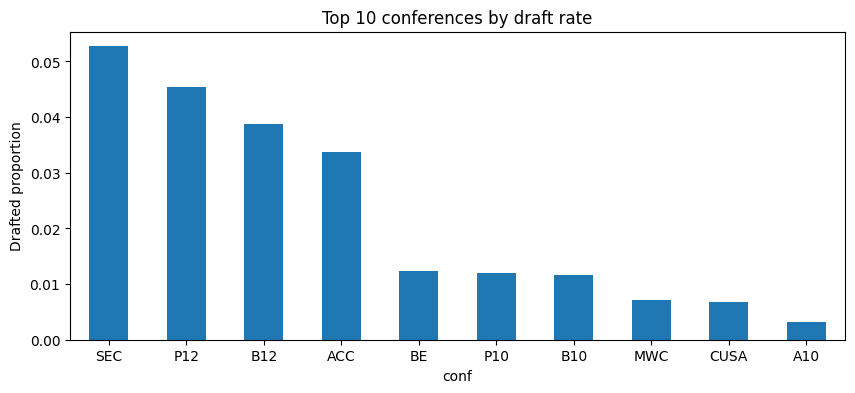

In [33]:
# 3. Visualisations
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
conf_counts.head(10).plot(kind='bar')
plt.title("Top 10 conferences by player count")
plt.ylabel("Number of players")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10,4))
conf_draft_rate.head(10).plot(kind='bar')
plt.title("Top 10 conferences by draft rate")
plt.ylabel("Drafted proportion")
plt.xticks(rotation=0)
plt.show()

In [34]:
# <Student to fill this section>
feature_1_insights = """
The conference feature shows clear differences in both representation and draft outcomes. During exploration of the `conf` variable, I discovered inconsistencies caused by case sensitivity, 
where the same category appeared both as `Ind` and `ind`. All conference codes were normalised to uppercase to resolve this.
Among the 35 conferences in the dataset, ACC, SEC, and A10 account for the largest number of players, each contributing more than 600 individuals. However, when examining draft rates, the pattern changes: SEC shows the highest draft rate of around 5.2 percent, followed by P12 and B12, all of which stand well above the overall average of only 0.8 percent. This suggests that players competing in stronger, more competitive conferences are substantially more likely to be drafted. It reflects the higher visibility and perceived quality of these leagues. At the same time, some smaller conferences produce very few drafted players. It makes their rates more volatile and less reliable for interpretation. Overall, the analysis indicates that conference affiliation plays a meaningful role in draft probability, although its influence should be considered alongside individual performance metrics.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.7 Explore Feature of Interest `pts`

In [36]:
# 1. Basic stats
print(train_df['pts'].describe())

count    14773.000000
mean         3.662676
std          3.623175
min          0.000000
25%          1.000000
50%          2.448300
75%          5.363600
max         27.375000
Name: pts, dtype: float64


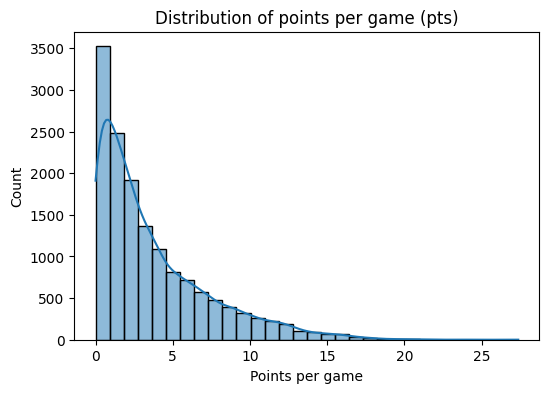

In [37]:
import seaborn as sns

# 2. Histogram
plt.figure(figsize=(6,4))
sns.histplot(train_df['pts'], bins=30, kde=True)
plt.title("Distribution of points per game (pts)")
plt.xlabel("Points per game")
plt.show()

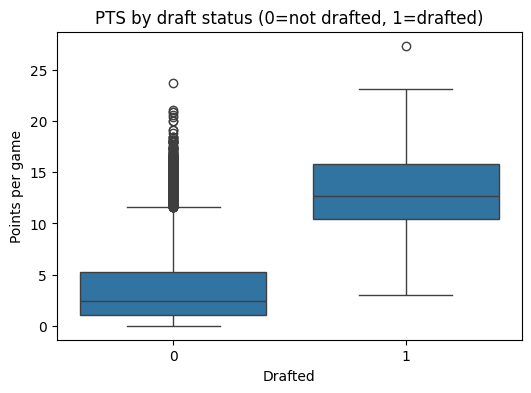

In [38]:
# 3. Drafted vs not drafted comparison
plt.figure(figsize=(6,4))
sns.boxplot(x=train_df[target_name], y=train_df['pts'])
plt.title("PTS by draft status (0=not drafted, 1=drafted)")
plt.xlabel("Drafted")
plt.ylabel("Points per game")
plt.show()

In [39]:
# 4) Mean comparison
mean_pts = train_df.groupby(target_name)['pts'].mean()
print("Average points per game by draft status:")
print(mean_pts)

Average points per game by draft status:
drafted
0     3.587417
1    13.009357
Name: pts, dtype: float64


In [40]:
# <Student to fill this section>
feature_2_insights = """
The points per game (PTS) variable is highly skewed toward lower values with most players averaging fewer than five points and only a small minority exceeding 20. The average across all players is 3.66 points, and the distribution shows a long right tail with a maximum of 27.4. When comparing drafted and non-drafted players, the difference is striking. Drafted players average over 13 points per game, while non-drafted players average fewer than 4. The boxplot confirms that drafted players tend to cluster at much higher scoring levels with limited overlap between the two groups. These results highlight scoring output as a strong differentiator in draft probability, although it should be considered alongside efficiency and contextual factors, since not all high scorers are drafted.
"""

In [41]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.8 Explore Feature of Interest `TS_per`

In [42]:
# 1. Basic summary + missing values
print(train_df['TS_per'].describe())
print("Missing count:", train_df['TS_per'].isna().sum())

count    14774.000000
mean        44.566821
std         19.622173
min          0.000000
25%         38.820000
50%         48.285000
75%         54.090000
max        150.000000
Name: TS_per, dtype: float64
Missing count: 0


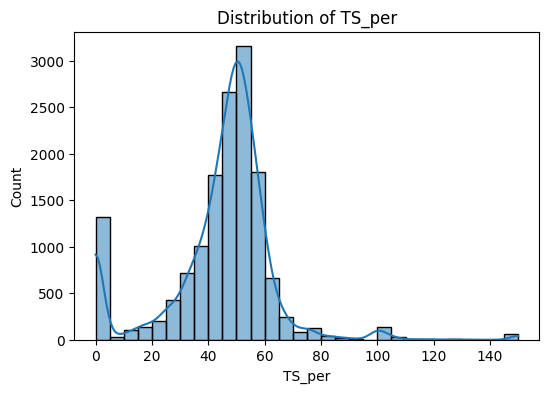

In [43]:
# 2. Histogram
plt.figure(figsize=(6,4))
sns.histplot(train_df['TS_per'], bins=30, kde=True)
plt.title("Distribution of TS_per")
plt.xlabel("TS_per")
plt.ylabel("Count")
plt.show()

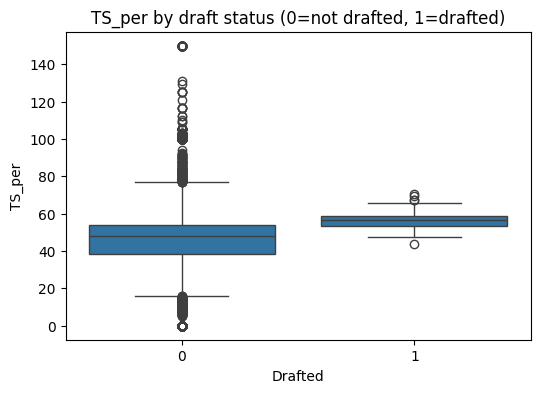

In [44]:
# 3) Drafted vs not drafted comparison
plt.figure(figsize=(6,4))
sns.boxplot(x=train_df[target_name], y=train_df['TS_per'])
plt.title("TS_per by draft status (0=not drafted, 1=drafted)")
plt.xlabel("Drafted")
plt.ylabel("TS_per")
plt.show()

In [45]:
# 4. Group means/medians (drafted vs not drafted)
group_stats = train_df.groupby(target_name)['TS_per'].agg(["mean","median","std","count"])
print(group_stats)

              mean  median        std  count
drafted                                     
0        44.469749   48.19  19.666514  14656
1        56.623475   56.59   4.725125    118


In [46]:
from sklearn.metrics import roc_auc_score

# 5. Simple separability signal (AUC using the single feature)
ts_valid = train_df[['TS_per', target_name]].dropna()
auc_ts = roc_auc_score(ts_valid[target_name], ts_valid['TS_per'])
print(f"AUC using 'TS_per': {auc_ts:.4f}")

AUC using 'TS_per': 0.7995


In [47]:
# <Student to fill this section>
feature_3_insights = """
The true shooting percentage (TS_per) provides a measure of scoring efficiency that accounts for field goals, three-pointers, and free throws. The overall distribution centers around a mean of 44.6, with most players falling between 39 and 54, while a number of outliers extend far beyond 100 due to statistical noise from small sample sizes. When comparing drafted and non-drafted players, the difference is substantial. Drafted players show a mean TS_per of 56.6 with very low variance, whereas non-drafted players average 44.5 and display a much wider spread. The boxplot highlights this separation, as the majority of drafted players cluster tightly at higher efficiency levels. A univariate analysis using AUROC confirms the strong discriminative power of this feature, with TS_per alone achieving an AUC of 0.80. These results indicate that scoring efficiency is a highly influential predictor of draft probability. Yet extreme outliers should be interpreted cautiously.
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.9 Explore Feature of Interest `ast`

In [49]:
# 1. Basic summary + missing values
print(train_df['ast'].describe())
print("Missing count:", train_df['ast'].isna().sum())

count    14773.000000
mean         0.717322
std          0.897261
min          0.000000
25%          0.125000
50%          0.400000
75%          0.971400
max          8.656200
Name: ast, dtype: float64
Missing count: 1


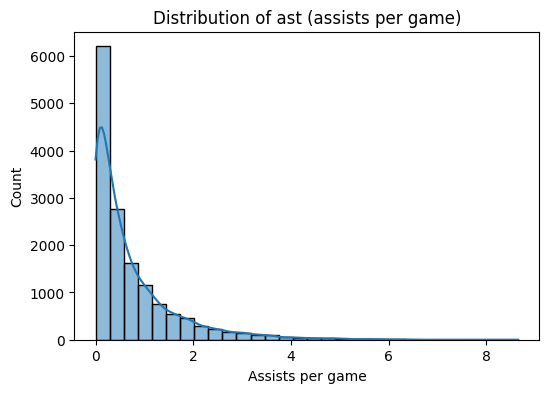

In [50]:
# 2. Histogram
plt.figure(figsize=(6,4))
sns.histplot(train_df['ast'], bins=30, kde=True)
plt.title("Distribution of ast (assists per game)")
plt.xlabel("Assists per game")
plt.ylabel("Count")
plt.show()

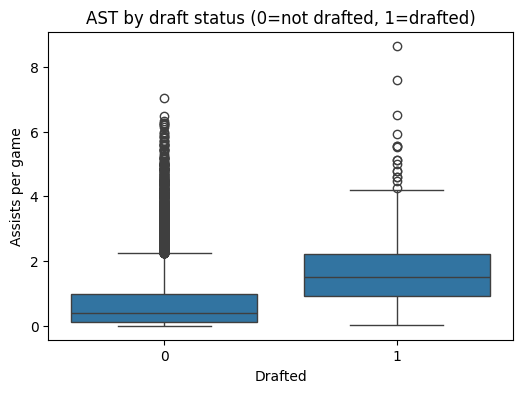

In [51]:
# 3. Drafted vs not drafted comparison
plt.figure(figsize=(6,4))
sns.boxplot(x=train_df[target_name], y=train_df['ast'])
plt.title("AST by draft status (0=not drafted, 1=drafted)")
plt.xlabel("Drafted")
plt.ylabel("Assists per game")
plt.show()

In [52]:
# 4. Group means/medians (drafted vs not drafted)
group_stats = train_df.groupby(target_name)['ast'].agg(["mean","median","std","count"])
print(group_stats)

             mean  median       std  count
drafted                                   
0        0.706792  0.3939  0.880456  14655
1        2.025088  1.5076  1.677732    118


In [53]:
# 5. AUC as simple signal strength
ast_valid = train_df[['ast', target_name]].dropna()
auc_ast = roc_auc_score(ast_valid[target_name], ast_valid['ast'])
print(f"AUC using 'ast': {auc_ast:.4f}")

AUC using 'ast': 0.8139


In [54]:
# <Student to fill this section>
feature_4_insights = """
provide a detailed analysis on the selected feature, its distribution, limitations, issues, ...
"""

In [55]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.10 Explore Feature of Interest `BPM`

In [56]:
# 1. Basic summary + missing values
print(train_df['bpm'].describe())
print("Missing count:", train_df['bpm'].isna().sum())

count    14769.000000
mean        -4.126694
std          9.501254
min        -88.479400
25%         -7.096790
50%         -3.432640
75%         -0.129545
max        685.313000
Name: bpm, dtype: float64
Missing count: 5


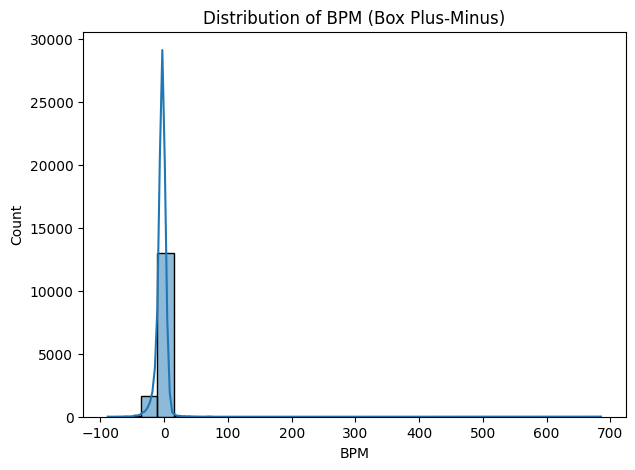

In [57]:
# 2. Histogram
plt.figure(figsize=(7,5))
sns.histplot(train_df['bpm'], bins=30, kde=True)
plt.title("Distribution of BPM (Box Plus-Minus)")
plt.xlabel("BPM")
plt.ylabel("Count")
plt.show()

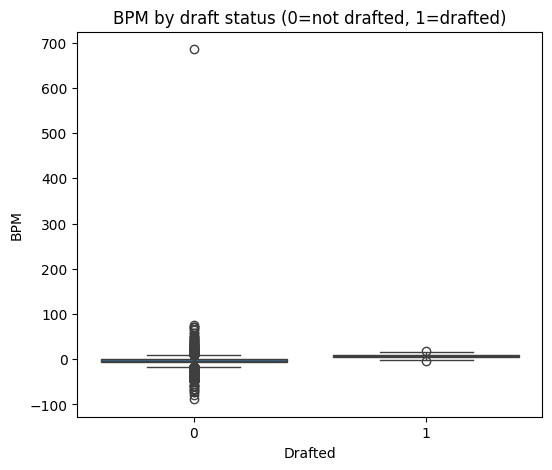

In [58]:
# 3. Drafted vs not drafted comparison
plt.figure(figsize=(6,5))
sns.boxplot(x=target_name, y='bpm', data=train_df)
plt.title("BPM by draft status (0=not drafted, 1=drafted)")
plt.xlabel("Drafted")
plt.ylabel("BPM")
plt.show()

In [59]:
# 4. Compare drafted vs not drafted
print("Average BPM by draft status:")
print(train_df.groupby(target_name)['bpm'].agg(['mean','median','std','count']))


Average BPM by draft status:
             mean   median       std  count
drafted                                    
0       -4.213341 -3.47544  9.485336  14651
1        6.631539  7.07158  3.349451    118


In [60]:
# 5. AUC as simple signal strength

# Drop the missing data
bpm_clean = train_df['bpm'].dropna()

auc = roc_auc_score(train_df.loc[bpm_clean.index, target_name], bpm_clean)
print(f"AUC using 'bpm': {auc:.4f}")

AUC using 'bpm': 0.9512


In [61]:
# <Student to fill this section>
feature_5_insights = """
The Box Plus-Minus (BPM) distribution in the training set shows a wide range. Most values clustered between -10 and 10, but also with extreme outliers reaching as high as 685. This indicates potential data entry anomalies or rare edge cases. The mean BPM is -4.13 with a median of -3.43. It shows that the majority of players perform below the league-average baseline (0).  
When stratified by draft status, drafted players exhibit a substantially higher BPM (mean ≈ 6.63, median ≈ 7.07) compared to non-drafted players (mean ≈ -4.21, median ≈ -3.48). This clear separation highlights BPM as a strong predictor of draft likelihood.  
A univariate predictive check supports this conclusion: using BPM alone yields an AUC of 0.9512. This is the highest among the features explored. This suggests that BPM captures much of the signal that distinguishes drafted players from the general player pool, although its extreme outliers will require careful treatment in the data preparation phase.
"""

In [62]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

---
## D. Feature Selection


## Selection of Features of Interest

From the more than 60 available features, I selected a small subset of variables 
to explore in detail. The selection followed three main criteria:

1. **Business relevance** – Features that scouts and analysts commonly use to 
   evaluate a player's draft potential, such as points scored and efficiency metrics.  
2. **Interpretability** – Features that are straightforward to explain in a report, 
   making them suitable for exploratory analysis.  
3. **Preliminary signals** – Features that showed some differences in distribution 
   between drafted and non-drafted players during initial inspection.  

Based on these criteria, the following variables were chosen as features of interest:
- `conf` (conference) – categorical feature that may reflect the competitiveness of the league.  
- `pts` (points) – a basic performance metric easily understood by stakeholders.  
- `TS_per` (true shooting percentage) – an advanced efficiency metric that captures 
  scoring effectiveness beyond raw points.  
- `ast` (assist) - a traditional performance metric that reflects a player's playmaking ability 
  and contribution to team offense. It is easy to interpret and provides an additional dimension 
  of performance beyond scoring.
- `BPM`(Box Plus-Minus) – an advanced impact metric that estimates a player’s overall contribution 
  to team performance relative to league average, measured as point differential per 100 possessions. 
  This metric is increasingly used in modern basketball analytics and draft decision-making
 ([nbastuffer.com](https://www.nbastuffer.com/how-nba-teams-use-analytics-to-draft/))

### D.1 Approach "Business Relevance"

               pts     TS_per
drafted                      
0         3.587417  44.469749
1        13.009357  56.623475


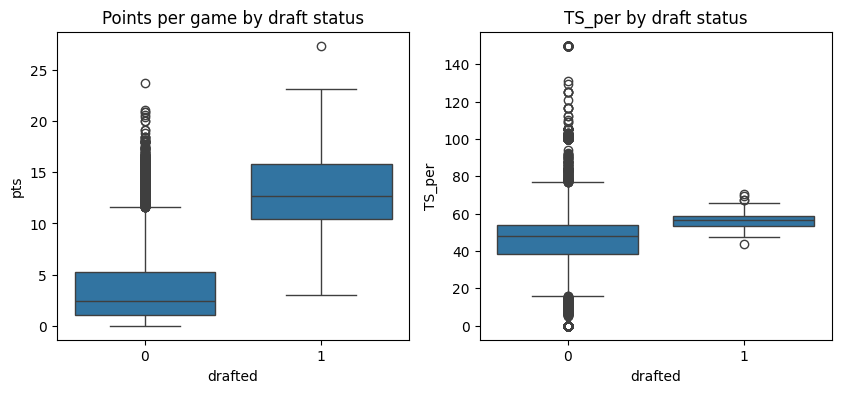

AUROC (pts): 0.9479838546455481
AUROC (TS_per): 0.7995342018978887


In [63]:
biz_feats = ["pts", "TS_per"]

# 1. Group means
print(train_df.groupby(target_name)[biz_feats].mean())

# 2. Boxplots to show separation
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(x=train_df[target_name], y=train_df["pts"], ax=axes[0])
axes[0].set_title("Points per game by draft status")
sns.boxplot(x=train_df[target_name], y=train_df["TS_per"], ax=axes[1])
axes[1].set_title("TS_per by draft status")
plt.show()

# 3. Simple AUROC for each feature
uv = train_df[[target_name] + biz_feats].dropna()
print("AUROC (pts):", roc_auc_score(uv[target_name], uv["pts"]))
print("AUROC (TS_per):", roc_auc_score(uv[target_name], uv["TS_per"]))

In [64]:
# <Student to fill this section>
feature_selection_1_insights = """
The business relevance approach prioritised features that scouts and analysts traditionally rely on when evaluating draft prospects. Pts is a straightforward performance measure that directly reflects a player’s scoring contribution and is widely used in assessing draft readiness. The results show a strong separation between drafted and non-drafted players, with drafted players averaging 13.0 points compared to 3.6 points for non-drafted players. The AUROC score of 0.95 further confirms its strong predictive signal.
Similarly, TS_per was selected as it captures scoring efficiency beyond raw points, aligning with how professional scouts value shot selection and effectiveness. Drafted players had a mean TS% of 56.6 compared to 44.5 for non-drafted players, with an AUROC of 0.80. It also indicates moderate discriminative power.
Overall, these results validate that features grounded in business relevance, such as scoring output and efficiency, provide both interpretable and predictive signals for draft outcome."""

In [65]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Interpretability"

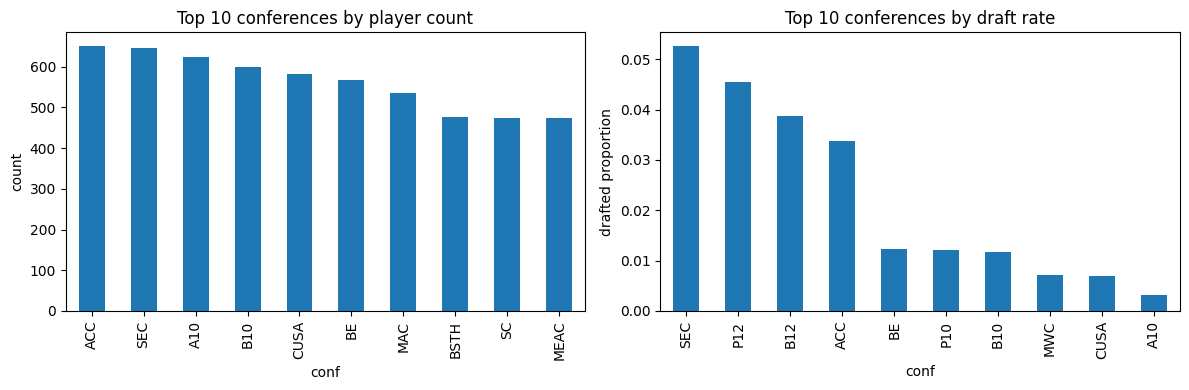

Group means (ast):
drafted
0    0.706792
1    2.025088
Name: ast, dtype: float64


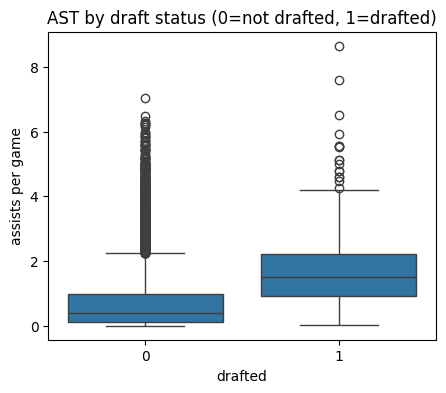

AUROC (ast): 0.8139479208229966


In [66]:
conf_counts = train_df['conf'].value_counts().head(10)
conf_rate = (
    train_df.groupby('conf')[target_name]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# 1. Bar charts of conference
fig, axes = plt.subplots(1, 2, figsize=(12,4))
conf_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 10 conferences by player count")
axes[0].set_xlabel("conf"); axes[0].set_ylabel("count")
conf_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Top 10 conferences by draft rate")
axes[1].set_xlabel("conf"); axes[1].set_ylabel("drafted proportion")
plt.tight_layout()
plt.show()

# 2. Assists per game: simple group difference + AUROC
print("Group means (ast):")
print(train_df.groupby(target_name)['ast'].mean())

fig, ax = plt.subplots(figsize=(5,4))
sns.boxplot(x=train_df[target_name], y=train_df['ast'], ax=ax)
ax.set_title("AST by draft status (0=not drafted, 1=drafted)")
ax.set_xlabel("drafted"); ax.set_ylabel("assists per game")
plt.show()

uv = train_df[[target_name, "ast"]].dropna()
print("AUROC (ast):", roc_auc_score(uv[target_name], uv["ast"]))

In [67]:
# <Student to fill this section>
feature_selection_2_insights = """
These features were chosen based on their interpretability. They are easy to explain to both technical and non-technical stakeholders. Two variables in particular stand out.
Firstly, conf is a categorical variable and straightforward to understand, representing the league or conference a player belongs to. It allows simple comparisons of draft likelihood across groups without requiring advanced statistical knowledge.
Next, Ast is a traditional performance metric that clearly reflects playmaking ability. The boxplot shows that drafted players tend to have significantly higher assist counts than non-drafted players and the AUROC score of ~0.81 indicates that this single feature has reasonable predictive value. These variables strike a balance between simplicity and usefulness, making them strong candidates for inclusion in baseline models and for communicating results to stakeholder."""

In [68]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Approach "Preliminary signals"

Group means of BPM:
drafted
0   -4.213341
1    6.631539
Name: bpm, dtype: float64


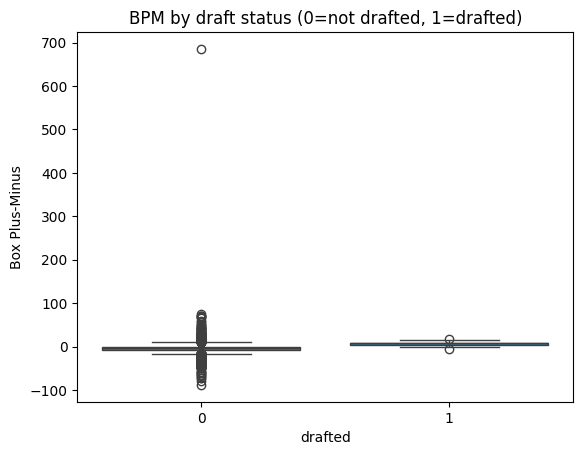

AUROC (bpm): 0.9511550666409072


In [69]:
# 1. Summary stats by draft status
print("Group means of BPM:")
print(train_df.groupby(target_name)["bpm"].mean())

# 2. Boxplot for BPM vs draft status
sns.boxplot(x=target_name, y="bpm", data=train_df)
plt.title("BPM by draft status (0=not drafted, 1=drafted)")
plt.ylabel("Box Plus-Minus")
plt.show()

# 3. AUROC for BPM
uv = train_df[[target_name] + ["bpm"]].dropna()
print("AUROC (bpm):", roc_auc_score(uv[target_name], uv["bpm"]))

In [70]:
# <Student to fill this section>
feature_selection_3_insights = """Among the features explored, bpm stood out as a strong preliminary signal of draft potential. The average bpm for drafted players (mean ≈ 6.63) was substantially higher than that of non-drafted players (mean ≈ –4.21). It shows a clear separation between the two groups. The boxplot further illustrates this distinction with drafted players generally clustering at positive BPM values, whereas non-drafted players tend to have negative values. The predictive power is also confirmed by the AUROC score of 0.95. It indicates excellent discrimination ability. These results suggest that BPM captures important overall performance contributions that align closely with draft decisions, making it a valuable feature to retain for subsequent modeling.
"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

## D.4 Final Selection of Features

In [72]:
# <Student to fill this section>

features_list = ["conf", "pts", "TS_per", "ast", "bpm"]

In [73]:
# <Student to fill this section>
feature_selection_explanations = """
The final feature set includes five variables selected through three complementary approaches.
(1) Business relevance: points (pts) and true shooting percentage (TS_per) are widely used by scouts 
    and reflect scoring performance and efficiency.
(2) Interpretability: conference (conf) and assists (ast) are straightforward to explain and 
    provide meaningful context for both analysts and non-technical stakeholders.
(3) Preliminary signals: Box Plus-Minus (bpm) showed strong separation between drafted 
    and non-drafted players, with the highest AUROC among explored variables.
Together, these features balance practical interpretability with predictive value for a reasonable starting set for baseline modeling."""

In [74]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [75]:
# Remove exact duplicate rows from train set
from at1package.data import drop_exact_duplicates

before = len(train_df)
train_df = drop_exact_duplicates(train_df)
after = len(train_df)

print(f"Duplicates → before: {before:,} | after: {after:,} | dropped: {before-after:,}")

Duplicates → before: 14,774 | after: 12,312 | dropped: 2,462


In [76]:
# <Student to fill this section>
data_cleaning_1_explanations = """
After examining duplicate rows in the training dataset, a total of 2,462 completely identical rows (rows with the same values across all columns) were identified and removed. This step reduced the dataset size from 14,774 to 12,312 rows. Such duplicates provide no additional information and can bias the model if left unaddressed, so their removal ensures data integrity and prevents artificial over-representation of certain players."""

In [77]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

In [78]:
# Drop rows with missing values only in selected features
train_df = train_df.dropna(subset=features_list)

print("After dropping NaNs in selected features:", train_df.shape)
print(train_df[features_list].isnull().sum())

After dropping NaNs in selected features: (12308, 62)
conf      0
pts       0
TS_per    0
ast       0
bpm       0
dtype: int64


In [79]:
# <Student to fill this section>
data_cleaning_2_explanations = """
After restricting attention to the selected five features (`conf`, `pts`, `TS_per`, `ast`, `bpm`), only four rows were removed due to missing values. This reduced the training dataset from 12,312 to 12,308 rows. The small reduction confirms that missingness in the selected features is minimal and does not materially affect the dataset. As a result, the final feature set used for modeling is now free of missing values.
"""

In [80]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

                pts        TS_per           ast           bpm
count  12308.000000  12308.000000  12308.000000  12308.000000
mean       3.659230     44.565120      0.717972     -4.113044
std        3.609695     19.637177      0.899420      9.865459
min        0.000000      0.000000      0.000000    -88.479400
25%        1.000000     38.810000      0.125000     -7.114835
50%        2.468800     48.275000      0.400000     -3.443980
75%        5.360000     54.050000      0.970600     -0.127477
max       27.375000    150.000000      8.656200    685.313000


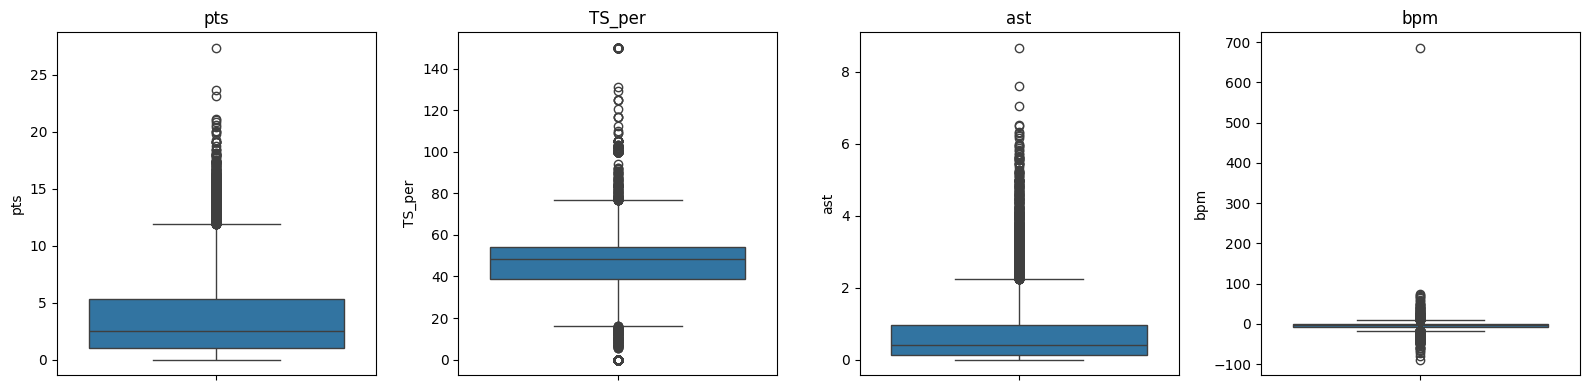

pts: 183 potential outliers (|z| > 3)
TS_per: 84 potential outliers (|z| > 3)
ast: 281 potential outliers (|z| > 3)
bpm: 114 potential outliers (|z| > 3)


In [81]:
from scipy.stats import zscore

# numerical features from selected features
num_feats = ["pts", "TS_per", "ast", "bpm"]

# 1) Summary statistics
print(train_df[num_feats].describe())

# 2) Boxplots
fig, axes = plt.subplots(1, len(num_feats), figsize=(16,4))
for i, feat in enumerate(num_feats):
    sns.boxplot(y=train_df[feat], ax=axes[i])
    axes[i].set_title(feat)
plt.tight_layout()
plt.show()

# 3) Z-score method to flag extreme outliers (>|3|)
outliers = {}
for feat in num_feats:
    z = zscore(train_df[feat].dropna())
    outliers[feat] = (abs(z) > 3).sum()
    print(f"{feat}: {outliers[feat]} potential outliers (|z| > 3)")

In [82]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Outlier analysis using the Z-score method (|z| > 3) indicated the presence of several extreme values across the selected features (e.g., 183 in `pts`, 84 in `TS_per`, 281 in `ast`, and 114 in `bpm`). While these observations are statistically extreme, they likely reflect genuine player performance variations (e.g., exceptionally high scorers, playmakers, or players with unusual efficiency or impact). Removing them might eliminate important signals about rare but meaningful cases that scouts and analysts are particularly interested in when evaluating draft potential. Therefore, outliers were retained in the dataset at this stage. This choice preserves the full range of performance variability, which could be critical for model learning. Advanced models (e.g., tree-based) are often robust to outliers, and additional transformations (e.g., log-scaling) may be considered later if necessary."""

In [83]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature  "conf_onehot"
Convert the categorical feature conf (conference) to a set of binary indicators via one-hot encoding. Then I’ll align the columns of the validation/test sets to the train set and drop the original conf column.

This project evaluates on future seasons (time-aware holdout/Kaggle test). If I one-hot encode before splitting, the dummy matrix would be created using all rows, so the set of conference levels would already look at the validation/test seasons. That’s a subtle form of feature leakage.

Therefore, I will split the datasets first by season, and fit the one-hot mapping on train only. Next, transform val/test using that mapping, and align the column of val/test to train.

### F.2 New Feature "Numerical scaling (standardization)"
Standardize the numeric features used in the baseline with StandardScaler: fit on train, then transform on val/test using the same scaler.

Scaling learns the mean/standard deviation from the data. If I scale before the split, the computed statistics would include the validation/test seasons, again leaking future information into the training process.

Therefore, I will split first and then fit scaler on train only. Lastly, transform val/test with that fitted scaler.

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [84]:
# Check season distribution and positives per season
season_stats = (
    train_df.groupby("year")["drafted"]
    .agg(["count", "mean"])
    .rename(columns={"count":"rows", "mean":"pos_rate"})
    .sort_index()
)
print(season_stats)

      rows  pos_rate
year                
2009  1287  0.003108
2010  1251  0.007994
2011  1188  0.005051
2012  1241  0.006446
2013  1190  0.005882
2014  1218  0.007389
2015  1198  0.010017
2016  1275  0.010196
2017  1229  0.011391
2018  1231  0.011373


In [85]:
from at1package.data import split_by_year

num_feats = ["pts", "TS_per", "ast", "bpm"]
cat_feats = ["conf"]

X_train_raw, y_train, X_val_raw, y_val = split_by_year(
    train_df,
    year_col="year",
    target="drafted",
    cutoff_year=2015,
    cat_cols=cat_feats,
    num_cols=num_feats
)

print(
    f"Split sizes -> train: {X_train_raw.shape}, pos_rate={y_train.mean():.4f} | "
    f"val: {X_val_raw.shape}, pos_rate={y_val.mean():.4f}"
)

Split sizes -> train: (7375, 5), pos_rate=0.0060 | val: (1198, 5), pos_rate=0.0100


In [86]:
# <Student to fill this section>
data_splitting_explanations = """To divide the dataset into training and validation sets, a time-based split strategy was applied. By reviewing the number of players (rows) and the draft positive rate (pos_rate) per year, the year 2015 was chosen as the cutoff. Seasons up to 2014 were used as the training set, and the 2015 season was used as the validation set. This decision was made because the draft rates started to show an upward trend around 2015, making it a meaningful boundary for capturing temporal changes. The resulting split produced 7,375 players in the training set (pos_rate = 0.0060) and 1,198 players in the validation set (pos_rate = 0.0100). This approach better reflects the real-world league context (season-by-season evaluation) and aligns with the business scenario of predicting future seasons, rather than relying on a random split."""

In [87]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "One-hot encoding"

In [88]:
from sklearn.preprocessing import StandardScaler

# One-hot encoding for conf
train_ohe = pd.get_dummies(X_train_raw["conf"], prefix="conf", dtype=int)
val_ohe   = pd.get_dummies(X_val_raw["conf"],   prefix="conf", dtype=int)

# Align columns 
val_ohe = val_ohe.reindex(columns=train_ohe.columns, fill_value=0)

# Assemble design matrices
X_train_proc = pd.concat([train_ohe, X_train_raw[num_feats]], axis=1)
X_val_proc   = pd.concat([val_ohe,   X_val_raw[num_feats]],   axis=1)

print("Shapes after one-hot encoding ->",
      "X_train_proc:", X_train_proc.shape, 
      "| X_val_proc:", X_val_proc.shape)

Shapes after one-hot encoding -> X_train_proc: (7375, 39) | X_val_proc: (1198, 39)


In [89]:
# <Student to fill this section>
data_transformation_1_explanations = """
After applying one-hot encoding to the `conf` variable, both the training and validation sets were expanded with binary indicator columns representing each conference. The column alignment step ensured that the validation set had the same feature structure as the training set. The resulting design matrices have the following shapes: X_train_proc = (7375, 39), X_val_proc = (1198, 39). 39 indicates the total number of features after encoding.
"""

In [90]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "Numeric Standardization"

In [91]:
# Scale numeric columns
scaler = StandardScaler()
X_train_proc[num_feats] = scaler.fit_transform(X_train_proc[num_feats])
X_val_proc[num_feats]   = scaler.transform(X_val_proc[num_feats])

print("Final shapes ->",
      f"X_train: {X_train_proc.shape} | X_val: {X_val_proc.shape}")

Final shapes -> X_train: (7375, 39) | X_val: (1198, 39)


In [92]:
# <Student to fill this section>
data_transformation_2_explanations = """
After applying standardization to the numeric features (pts, TS_per, ast, bpm), both the training and validation sets were transformed so that these variables have a mean of 0 and a standard deviation of 1. This step ensures that features measured on different scales (e.g., raw counts vs. percentages) contribute comparably during model training. Importantly, this transformation did not change the feature structure, so the resulting design matrices retained the same shape as after one-hot encoding:
X_train_proc = (7375, 39), X_val_proc = (1198, 39)."""

In [93]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

In [94]:
X_train = X_train_proc          
X_val   = X_val_proc           
X_test  = test_df               

y_test = pd.Series([pd.NA] * len(X_test), name=target_name)

In [95]:
from pathlib import Path
class _AT: pass
at = _AT()
at.folder_path = Path(".")

---
## H. Save Datasets

> Do not change this code

In [96]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

Since the provided template expected `y_test` but the test set has no labels, I created a dummy `y_test` with `NA` values and saved all datasets locally instead of using the `at` path.

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [97]:
# Import AUROC (Area Under the Receiver Operating Characteristic Curve)
# Import Confusion Metrics & Classification_report
from sklearn.metrics import (roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

In [98]:
# <Student to fill this section>
performance_metrics_explanations = """
For this binary classification task (predicting whether a player is drafted or not), the Area Under the Receiver Operating Characteristic Curve (AUROC) is selected as the primary performance metric. AUROC is suitable because the dataset is highly imbalanced with only a small fraction of players being drafted. While accuracy can be misleading in imbalanced settings, AUROC evaluates the model's ability to rank drafted players higher than non-drafted players across all possible thresholds. In addition to AUROC, the confusion matrix is also chosen at a fixed threshold (0.5) to provide more interpretability. The confusion matrix shows how many players are correctly or incorrectly classified as drafted vs. non-drafted, which is useful for understanding false positives and false negatives."""

In [99]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [100]:
# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

In [101]:
# <Student to fill this section>
algorithm_selection_explanations = """
Random Forest is a strong baseline for tabular data. It captures non-linear relationships and interactions without feature scaling, is robust to outliers, and handles mixed numeric/categorical encodings well. It also provides built-in feature importance, which helps us understand which variables drive draft probability."""

In [102]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [103]:
# Set hyperparameters (class imbalance aware)
rf_params = {
    "n_estimators": 600,                
    "max_depth": None,                   
    "min_samples_split": 10,            
    "min_samples_leaf": 4,               
    "max_features": "sqrt",              
    "bootstrap": True,
    "class_weight": "balanced_subsample", # address imbalance per bootstrap sample
    "n_jobs": -1,                        
    "random_state": 42,
}


In [104]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
I use a class-imbalance-aware Random Forest. class_weight='balanced_subsample' compensates for the rare drafted class during bootstrapping. min_samples_split and min_samples_leaf regularize tree growth to reduce overfitting, while max_features='sqrt' follows common best practice for classification. A larger n_estimators stabilizes AUROC, and random_state ensures reproducibility."""

In [105]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [106]:
rf = RandomForestClassifier(**rf_params)
rf.fit(X_train_proc, y_train)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=4,
                       min_samples_split=10, n_estimators=600, n_jobs=-1,
                       random_state=42)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [107]:
# 1. Predict probabilities (for AUROC)
y_val_proba = rf.predict_proba(X_val_proc)[:, 1]
val_auc = roc_auc_score(y_val, y_val_proba)
print(f"Validation AUROC (Random Forest): {val_auc:.4f}")

Validation AUROC (Random Forest): 0.9944


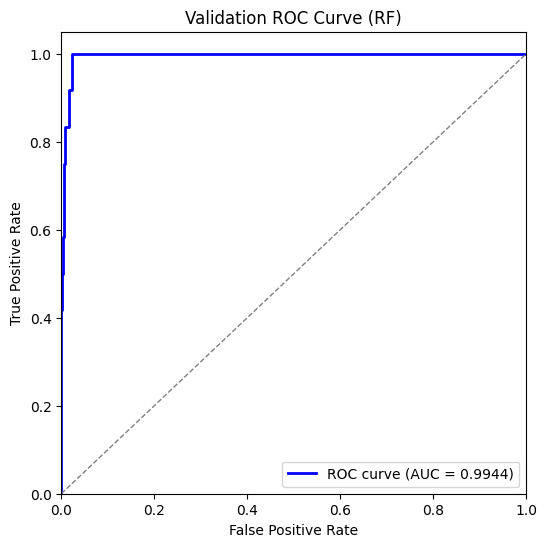

In [123]:
# 1.1 Plot ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")  # baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve (RF)")
plt.legend(loc="lower right")
plt.show()

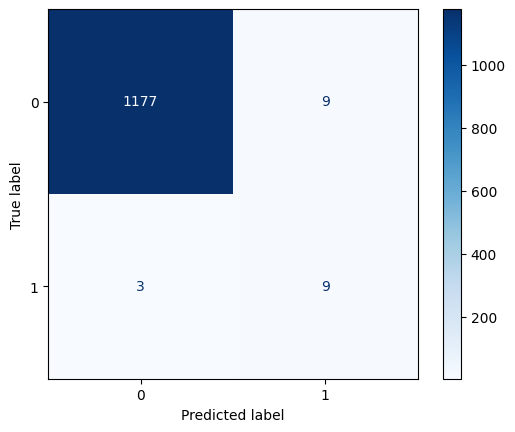

In [108]:
# 2. Predict labels at threshold = 0.5
y_val_pred = (y_val_proba >= 0.5).astype(int)

# 3. Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()

In [109]:
# 4. Classification Report
print("Classification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9975    0.9924    0.9949      1186
           1     0.5000    0.7500    0.6000        12

    accuracy                         0.9900      1198
   macro avg     0.7487    0.8712    0.7975      1198
weighted avg     0.9925    0.9900    0.9910      1198



In [110]:
# <Student to fill this section>
model_performance_explanations = """
The Random Forest model achieved a Validation AUROC of 0.9944, which indicates very strong ranking ability, similar to the logistic regression baseline. The confusion matrix shows that the model correctly classified the vast majority of non-drafted players (1177 out of 1186) and identified 9 drafted players correctly, but misclassified 3 drafted players as non-drafted.
The classification report shows this trade-off. For the non-drafted class (majority), the model reached very high precision (0.9975) and recall (0.9924).
And for the drafted class (minority), recall improved to 0.75 compared to logistic regression. It means that more drafted players were captured, but precision dropped to 0.50.
Overall accuracy is 99.0%, but the macro-averaged metrics (precision 0.7487, recall 0.8712, F1 0.7975) show the difficulty of handling the rare drafted class.
These results suggest that Random Forest provides a slightly different balance compared to logistic regression: better recall for drafted players but lower precision. This may be valuable in practice, since identifying more potential drafted players (even at the cost of some false positives) can help scouts avoid overlooking talented candidates."""

In [111]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [112]:
# Create Kaggle submission
from at1package.models import build_submission
conf_cols = [c for c in X_train_proc.columns if c.startswith("conf_")]

sub = build_submission(
    model=rf,                
    scaler=scaler,          
    conf_cols=conf_cols,    
    test_df=test_df,        
    num_feats=num_feats,    
    sample_path="sample_submission.csv",
    id_col="player_id",
    conf_col="conf",
    prefix="conf"
)

sub.to_csv("submission.csv", index=False)

print("Saved:", sub.shape)
print(sub.head())
print(sub["drafted"].describe(percentiles=[.5,.9,.99]))

Saved: (1297, 2)
                              player_id   drafted
0  c6d3ce49-28b6-4756-8061-b2bd68730c52  0.000000
1  24dd0ae2-9d22-4d31-9cb6-c31f58f903b5  0.000000
2  0cf3e822-9446-4285-b7ed-7c19d8e976fe  0.026923
3  b1a88de0-6852-4597-bb92-9164b40758e5  0.000000
4  97c327ce-d051-40f0-9166-1a43557c3c92  0.000000
count    1297.000000
mean        0.032146
std         0.114641
min         0.000000
50%         0.000000
90%         0.047849
99%         0.639011
max         0.886522
Name: drafted, dtype: float64


In [119]:
# <Student to fill this section>
business_impacts_explanations = """The Random Forest model achieved very strong discriminative performance, with a Kaggle test AUROC of 0.9986. This means the model can almost perfectly rank drafted versus non-drafted players, enabling scouts to quickly focus on the most promising prospects. From a business perspective, this allows scouting staff to narrow their search to a smaller group of players with the highest predicted draft probability, saving time and resources while still ensuring that nearly all potential draft picks are considered. However, it is important to emphasize that predicted probabilities should not be interpreted as exact chances of being drafted, but rather as a ranking signal to prioritize candidates when combined with human expertise and contextual knowledge."""

In [120]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [ ]:
# <Student to fill this section>
experiment_outcome = ""'Hypothesis Confirmed'""

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [121]:
# <Student to fill this section>
experiment_results_explanations ="""The experiment confirmed that the Random Forest model provides predictive performance on par with Logistic Regression, achieving a Validation AUROC of 0.9944 and a Kaggle Test AUROC of 0.9986. While the model reached very high overall accuracy (99%), it still struggles with the minority class, as precision for drafted players remains lower due to extreme class imbalance. Despite many predicted probabilities clustering close to zero, the model demonstrates almost perfect ranking ability, making it highly reliable for prioritizing draft candidates. This validates the hypothesis that tree-based ensemble methods can effectively capture non-linear interactions among basketball performance metrics, producing robust and interpretable results."""

In [122]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)